# Insurance Claims Frequency and Severity Modelling

**Domain:** Insurance  
**Dataset:** French Motor Third-Party Liability (MTPL) Insurance (`CASdatasets`)  
**Language:** R

---

## Business Problem

Insurance pricing depends on two related but distinct components: how often a policyholder is expected 
to file a claim (**frequency**) and how large that claim is expected to be when it occurs (**severity**). 
Multiplying expected frequency by expected severity yields the **pure premium** — the actuarially fair 
claim cost before expenses and profit loading.

In property and casualty insurance, this two-part modelling framework is standard practice and underpins 
generalised linear model (GLM) pricing across personal and commercial lines. A well-specified frequency–
severity model produces interpretable rating factors and supports transparent, defensible pricing decisions.

This project implements a full frequency–severity workflow on a real French motor insurance portfolio, 
mirroring what an actuarial data scientist would build in a commercial lines pricing team.

**Central question:**  
What is the actuarially fair pure premium for each policyholder, and which rating factors have the largest effect on expected claims cost?

---

### Notebook structure:
1. Setup and data loading  
2. Data preparation and exposure structure  
3. Exploratory analysis  
4. Frequency model — Poisson / Negative Binomial  
5. Severity model — Gamma / Tweedie  
6. Pure premium construction  
7. Model validation  
8. Results summary and interpretation

*industry_projects — Samantha McGarrigle*

## 1. Setup and Data Loading

We work with the French Motor Third-Party Liability (MTPL) insurance datasets from the `CASdatasets` package:

- `freMTPL2freq`: policy-level exposure and claim counts (frequency)  
- `freMTPL2sev`: claim-level amounts for policies with at least one claim (severity)

These datasets are widely used in actuarial science as benchmark data for pricing and GLM modelling.


In [11]:
library(CASdatasets)
library(tidyverse)
library(MASS)
library(DHARMa)
library(broom)
library(ggplot2)

data("freMTPL2freq")
data("freMTPL2sev")

freq_raw <- freMTPL2freq
sev_raw  <- freMTPL2sev

glimpse(freq_raw)
glimpse(sev_raw)


Rows: 677,991
Columns: 12
$ IDpol      <fct> 1, 3, 5, 10, 11, 13, 15, 17, 18, 21, 25, 27, 30, 32, 35, 36…
$ ClaimNb    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Exposure   <dbl> 0.10, 0.77, 0.75, 0.09, 0.84, 0.52, 0.45, 0.27, 0.71, 0.15,…
$ VehPower   <int> 5, 5, 6, 7, 7, 6, 6, 7, 7, 7, 7, 7, 4, 4, 4, 9, 6, 6, 6, 6,…
$ VehAge     <int> 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 9, 0, 2, 2, 2, 2,…
$ DrivAge    <int> 55, 55, 52, 46, 46, 38, 38, 33, 33, 41, 41, 56, 27, 27, 23,…
$ BonusMalus <int> 50, 50, 50, 50, 50, 50, 50, 68, 68, 50, 50, 50, 90, 90, 100…
$ VehBrand   <fct> B12, B12, B12, B12, B12, B12, B12, B12, B12, B12, B12, B12,…
$ VehGas     <fct> Regular, Regular, Diesel, Diesel, Diesel, Regular, Regular,…
$ Area       <fct> D, D, B, B, B, E, E, C, C, B, B, C, D, D, E, F, A, A, A, A,…
$ Density    <int> 1217, 1217, 54, 76, 76, 3003, 3003, 137, 137, 60, 60, 173, …
$ Region     <fct> Rhone-Alpes, Rhone-Alpes, Picardie, Aquitaine, Aquitaine, N…
Rows: 26,444
C

We now construct basic derived quantities:

- **Claim frequency:** claim count per policy-year (using exposure as the offset)  
- **Claim severity:** average claim amount per claim (from the severity dataset)

These will form the response variables for the frequency and severity GLMs.

In [15]:
# Aggregate severity to policy level
sev_policy <- sev_raw %>%
  group_by(IDpol) %>%
  summarise(
    n_claims_sev = n(),
    avg_claim    = mean(ClaimAmount),
    .groups = "drop"
  )

# Join frequency and severity datasets
claims_df <- freq_raw %>%
  rename(
    policy_id = IDpol,
    exposure  = Exposure,
    n_claims  = ClaimNb
  ) %>%
  left_join(sev_policy, by = c("policy_id" = "IDpol"))

# Replace missing severity with 0
claims_df <- claims_df %>%
  mutate(
    avg_claim = if_else(is.na(avg_claim), 0, avg_claim),
    freq_rate = n_claims / exposure
  )

glimpse(claims_df)

Rows: 677,991
Columns: 15
$ policy_id    <fct> 1, 3, 5, 10, 11, 13, 15, 17, 18, 21, 25, 27, 30, 32, 35, …
$ n_claims     <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ exposure     <dbl> 0.10, 0.77, 0.75, 0.09, 0.84, 0.52, 0.45, 0.27, 0.71, 0.1…
$ VehPower     <int> 5, 5, 6, 7, 7, 6, 6, 7, 7, 7, 7, 7, 4, 4, 4, 9, 6, 6, 6, …
$ VehAge       <int> 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 9, 0, 2, 2, 2, …
$ DrivAge      <int> 55, 55, 52, 46, 46, 38, 38, 33, 33, 41, 41, 56, 27, 27, 2…
$ BonusMalus   <int> 50, 50, 50, 50, 50, 50, 50, 68, 68, 50, 50, 50, 90, 90, 1…
$ VehBrand     <fct> B12, B12, B12, B12, B12, B12, B12, B12, B12, B12, B12, B1…
$ VehGas       <fct> Regular, Regular, Diesel, Diesel, Diesel, Regular, Regula…
$ Area         <fct> D, D, B, B, B, E, E, C, C, B, B, C, D, D, E, F, A, A, A, …
$ Density      <int> 1217, 1217, 54, 76, 76, 3003, 3003, 137, 137, 60, 60, 173…
$ Region       <fct> Rhone-Alpes, Rhone-Alpes, Picardie, Aquitaine, Aquitaine,…
$ n_claims_sev

## 2. Data Preparation and Exposure Structure

Before modelling, we document the structure of the dataset and construct the key derived variables used in actuarial frequency–severity modelling.

Key elements:
- Exposure determines how long each policy was at risk.
- Claim count is modelled relative to exposure using a log(exposure) offset.
- Severity is modelled only for policies with claims.
- Rating factors are treated as categorical predictors.

In [16]:
claims_df <- claims_df %>%
  mutate(
    vehicle_age     = as.factor(VehAge),
    vehicle_power   = as.factor(VehPower),
    vehicle_brand   = as.factor(VehBrand),
    vehicle_gas     = as.factor(VehGas),
    driver_age      = as.factor(DrivAge),
    region          = as.factor(Region),
    area            = as.factor(Area)
  )

claims_df %>%
  summarise(
    total_policies = n(),
    total_exposure = sum(exposure),
    total_claims   = sum(n_claims),
    avg_freq       = sum(n_claims) / sum(exposure),
    avg_severity   = mean(avg_claim[avg_claim > 0])
  )


total_policies,total_exposure,total_claims,avg_freq,avg_severity
<int>,<dbl>,<dbl>,<dbl>,<dbl>
677991,358482.8,26444,0.07376643,2221.379


## 3. Exploratory Data Analysis

We explore claim frequency and severity across key rating factors to understand:

- Variation in frequency by driver age, vehicle power, region  
- Severity distribution for policies with claims  
- Exposure distribution  
- Zero inflation and skewness  

These insights guide GLM specification.

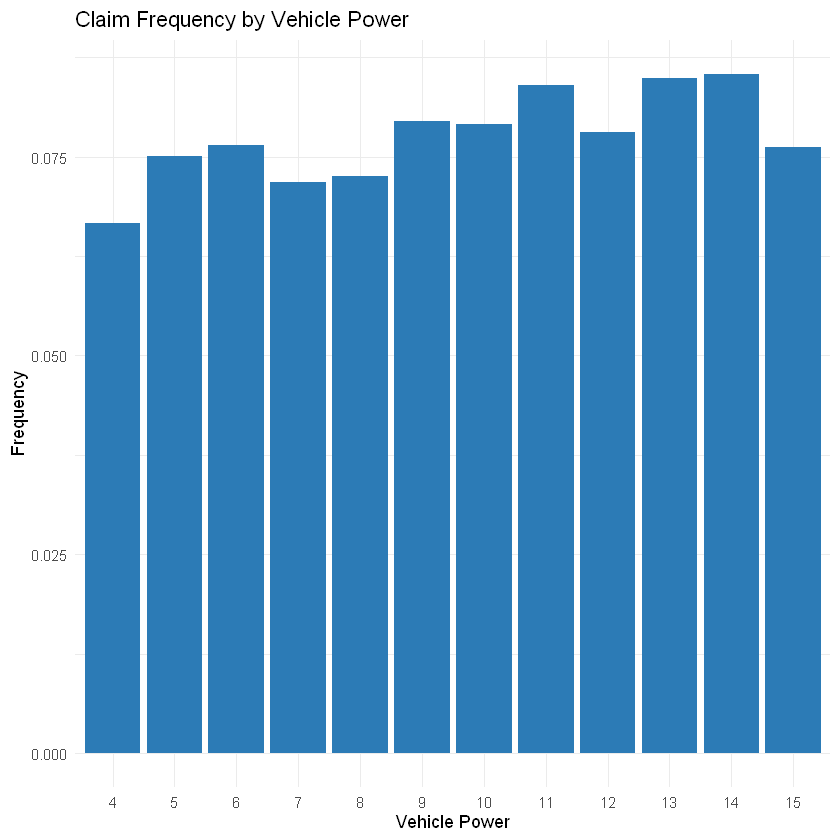

In [17]:
# Frequency by vehicle power
claims_df %>%
  group_by(vehicle_power) %>%
  summarise(
    exposure = sum(exposure),
    freq     = sum(n_claims) / sum(exposure)
  ) %>%
  ggplot(aes(x = vehicle_power, y = freq)) +
  geom_col(fill = "#2C7BB6") +
  labs(
    title = "Claim Frequency by Vehicle Power",
    x = "Vehicle Power",
    y = "Frequency"
  ) +
  theme_minimal()

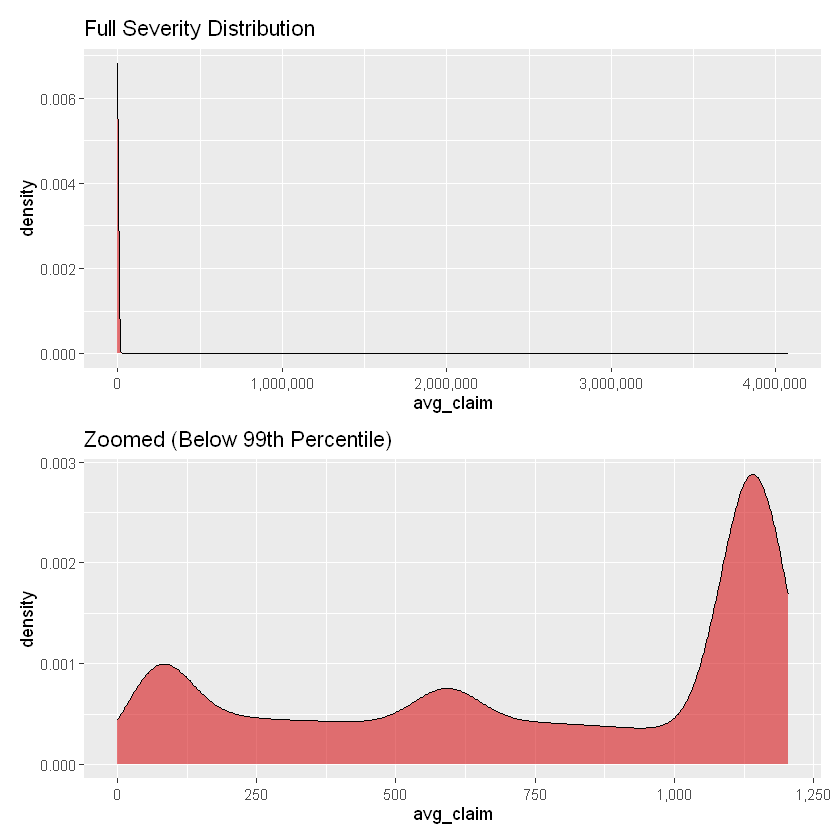

In [22]:
# Severity distribution
library(patchwork)

p1 <- claims_df %>%
  filter(avg_claim > 0) %>%
  ggplot(aes(x = avg_claim)) +
  geom_density(fill = "#D7191C", alpha = 0.6) +
  scale_x_continuous(labels = scales::comma) +
  labs(title = "Full Severity Distribution")

p2 <- claims_df %>%
  filter(avg_claim > 0, avg_claim < quantile(avg_claim, 0.99)) %>%
  ggplot(aes(x = avg_claim)) +
  geom_density(fill = "#D7191C", alpha = 0.6) +
  scale_x_continuous(labels = scales::comma) +
  labs(title = "Zoomed (Below 99th Percentile)")

p1 / p2

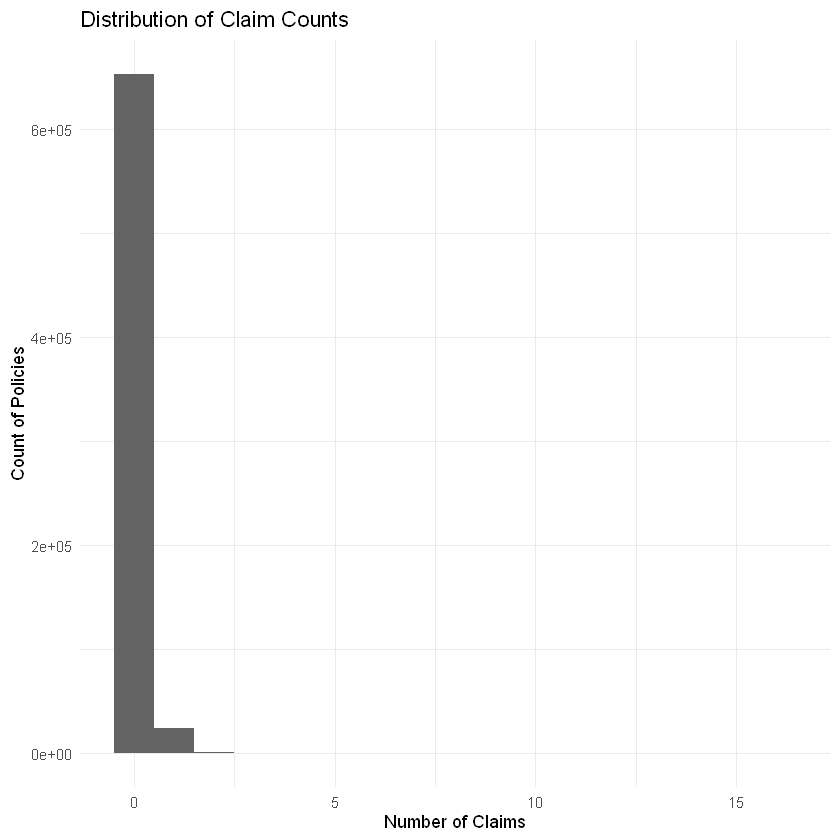

In [23]:
# Claim count distribution
claims_df %>%
  ggplot(aes(x = n_claims)) +
  geom_histogram(binwidth = 1, fill = "#636363") +
  labs(
    title = "Distribution of Claim Counts",
    x = "Number of Claims",
    y = "Count of Policies"
  ) +
  theme_minimal()

## 4. Frequency Model — Poisson and Negative Binomial GLM

Claim frequency is modelled using a count regression framework with exposure as an offset.

The standard actuarial approach:

- **Poisson GLM** with log link  
- **log(exposure)** as an offset  

However, claim counts often exhibit **overdispersion** (variance > mean).  
If present, a **Negative Binomial GLM** provides a more flexible alternative.

We fit both models and compare:

- Goodness of fit  
- Overdispersion  
- Interpretability  

Diagnostics use `DHARMa` for simulation-based residual checks.

In [24]:
# Poisson GLM with exposure offset
freq_poisson <- glm(
  n_claims ~ vehicle_power + driver_age + region + area,
  offset = log(exposure),
  data = claims_df,
  family = poisson(link = "log")
)

summary(freq_poisson)


Call:
glm(formula = n_claims ~ vehicle_power + driver_age + region + 
    area, family = poisson(link = "log"), data = claims_df, offset = log(exposure))

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                       -1.615e+00  1.648e-01  -9.803  < 2e-16 ***
vehicle_power5                     1.409e-01  2.113e-02   6.667 2.61e-11 ***
vehicle_power6                     1.915e-01  2.029e-02   9.441  < 2e-16 ***
vehicle_power7                     1.299e-01  2.079e-02   6.249 4.12e-10 ***
vehicle_power8                     1.382e-01  2.940e-02   4.700 2.60e-06 ***
vehicle_power9                     1.946e-01  3.276e-02   5.941 2.83e-09 ***
vehicle_power10                    2.143e-01  3.287e-02   6.518 7.11e-11 ***
vehicle_power11                    2.974e-01  4.079e-02   7.290 3.10e-13 ***
vehicle_power12                    2.199e-01  6.036e-02   3.643 0.000270 ***
vehicle_power13                    2.689e-01  8.635e-02   3.

In [25]:
# Check for overdispersion
overdispersion_ratio <- sum(residuals(freq_poisson, type = "pearson")^2) /
  freq_poisson$df.residual

overdispersion_ratio

[1] 1.750057

In [26]:
# Negative Binomial GLM if overdispersed
freq_nb <- MASS::glm.nb(
  n_claims ~ vehicle_power + driver_age + region + area + offset(log(exposure)),
  data = claims_df
)

summary(freq_nb)


Call:
MASS::glm.nb(formula = n_claims ~ vehicle_power + driver_age + 
    region + area + offset(log(exposure)), data = claims_df, 
    init.theta = 0.6707432442, link = log)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                       -1.557e+00  1.746e-01  -8.915  < 2e-16 ***
vehicle_power5                     1.398e-01  2.193e-02   6.374 1.84e-10 ***
vehicle_power6                     1.905e-01  2.106e-02   9.047  < 2e-16 ***
vehicle_power7                     1.273e-01  2.155e-02   5.906 3.51e-09 ***
vehicle_power8                     1.353e-01  3.048e-02   4.437 9.12e-06 ***
vehicle_power9                     1.931e-01  3.408e-02   5.666 1.46e-08 ***
vehicle_power10                    2.099e-01  3.419e-02   6.140 8.28e-10 ***
vehicle_power11                    2.940e-01  4.248e-02   6.921 4.48e-12 ***
vehicle_power12                    2.145e-01  6.276e-02   3.417 0.000633 ***
vehicle_power13                    2.58

DHARMa:testOutliers with type = binomial may have inflated Type I error rates for integer-valued distributions. To get a more exact result, it is recommended to re-run testOutliers with type = 'bootstrap'. See ?testOutliers for details



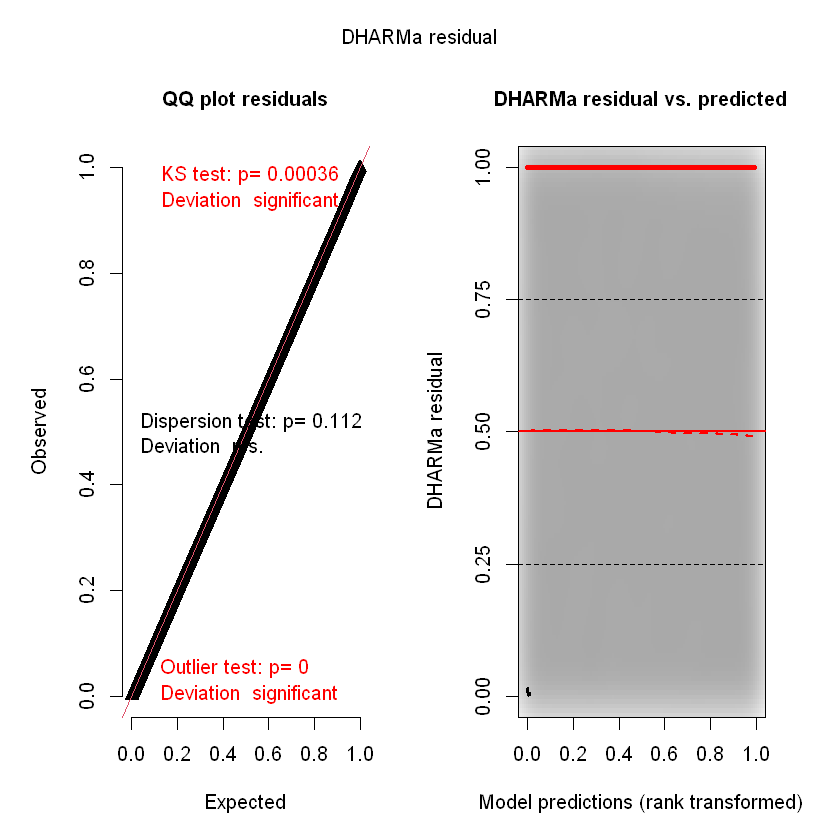

In [27]:
# DHARMa diagnostics
sim_nb <- DHARMa::simulateResiduals(freq_nb)
plot(sim_nb)

## 5. Severity Model — Gamma GLM and Tweedie Alternative

Severity is modelled **conditional on a claim occurring**, using only policies with positive claim amounts.

The standard actuarial model:

- **Gamma GLM** with log link  
- Suitable for positive, right-skewed data  

We also fit a **Tweedie GLM**, which combines frequency and severity into a single model.  
Tweedie is widely used in modern actuarial pricing but is less interpretable.

We compare:

- Fit  
- Interpretability  
- Pricing implications  

In [33]:
# Subset to policies with claims
sev_df <- claims_df %>%
  filter(avg_claim > 0) %>%
  droplevels()

# Gamma GLM
sev_gamma <- glm(
  avg_claim ~ vehicle_power + driver_age + region + area,
  data = sev_df,
  family = Gamma(link = "log")
)

summary(sev_gamma)


Call:
glm(formula = avg_claim ~ vehicle_power + driver_age + region + 
    area, family = Gamma(link = "log"), data = sev_df)

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        9.788613   0.643447  15.213  < 2e-16 ***
vehicle_power5                    -0.102757   0.082004  -1.253 0.210191    
vehicle_power6                     0.083091   0.078614   1.057 0.290547    
vehicle_power7                     0.051841   0.080461   0.644 0.519390    
vehicle_power8                    -0.052905   0.113615  -0.466 0.641470    
vehicle_power9                     0.121741   0.126404   0.963 0.335503    
vehicle_power10                    0.118492   0.127534   0.929 0.352846    
vehicle_power11                    0.045492   0.158673   0.287 0.774341    
vehicle_power12                    0.278721   0.233145   1.195 0.231910    
vehicle_power13                    0.228789   0.329795   0.694 0.487858    
vehicle_power14       

In [34]:
# Tweedie GLM
library(statmod)
library(tweedie)

sev_tweedie <- glm(
  avg_claim ~ vehicle_power + driver_age + region + area,
  data = sev_df,
  family = tweedie(var.power = 1.5, link.power = 0)  # log link
)

summary(sev_tweedie)


Call:
glm(formula = avg_claim ~ vehicle_power + driver_age + region + 
    area, family = tweedie(var.power = 1.5, link.power = 0), 
    data = sev_df)

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        9.744328   0.597185  16.317  < 2e-16 ***
vehicle_power5                    -0.144641   0.093094  -1.554 0.120267    
vehicle_power6                     0.063392   0.087415   0.725 0.468343    
vehicle_power7                     0.043773   0.089608   0.488 0.625202    
vehicle_power8                    -0.089357   0.130255  -0.686 0.492709    
vehicle_power9                     0.399519   0.132150   3.023 0.002503 ** 
vehicle_power10                    0.132487   0.141219   0.938 0.348166    
vehicle_power11                    0.013782   0.181449   0.076 0.939457    
vehicle_power12                    0.285692   0.252394   1.132 0.257675    
vehicle_power13                    0.222175   0.358269   0.620 0.535175 

In [35]:
# Compare fitted values
sev_df %>%
  mutate(
    gamma_pred   = predict(sev_gamma, type = "response"),
    tweedie_pred = predict(sev_tweedie, type = "response")
  ) %>%
  dplyr::select(avg_claim, gamma_pred, tweedie_pred) %>%
  head()

,avg_claim,gamma_pred,tweedie_pred
,<dbl>,<dbl>,<dbl>
1,303.00,2368.949,2388.7660
2,1981.84,2642.585,2802.7040
3,1456.55,1687.802,1717.4878
4,5417.00,1421.424,1427.0589
5,3986.67,1079.203,989.8587
6,1840.14,2435.956,2417.9227


## 6. Pure Premium Construction and Rating Relativities

The pure premium is the central actuarial quantity:



\[
\text{Pure Premium} = \text{Predicted Frequency} \times \text{Predicted Severity}
\]



We use:

- Negative Binomial model for frequency  
- Gamma GLM for severity  

We compute:

- Predicted frequency  
- Predicted severity  
- Pure premium  
- Relativities by rating factor 

In [36]:
# Align levels
claims_df <- claims_df %>%
  mutate(
    driver_age    = factor(driver_age, levels = levels(sev_df$driver_age)),
    vehicle_power = factor(vehicle_power, levels = levels(sev_df$vehicle_power)),
    region        = factor(region, levels = levels(sev_df$region)),
    area          = factor(area, levels = levels(sev_df$area))
  )

# Predicted frequency (NB model)
claims_df <- claims_df %>%
  mutate(
    freq_pred = predict(freq_nb, type = "response")
  )

# Predicted severity (Gamma model)
claims_df <- claims_df %>%
  mutate(
    sev_pred = predict(sev_gamma, newdata = claims_df, type = "response")
  )

# Pure premium
claims_df <- claims_df %>%
  mutate(
    pure_premium = freq_pred * sev_pred
  )

glimpse(claims_df)

Rows: 677,991
Columns: 25
$ policy_id     <fct> 1, 3, 5, 10, 11, 13, 15, 17, 18, 21, 25, 27, 30, 32, 35,…
$ n_claims      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ exposure      <dbl> 0.10, 0.77, 0.75, 0.09, 0.84, 0.52, 0.45, 0.27, 0.71, 0.…
$ VehPower      <int> 5, 5, 6, 7, 7, 6, 6, 7, 7, 7, 7, 7, 4, 4, 4, 9, 6, 6, 6,…
$ VehAge        <int> 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 9, 0, 2, 2, 2,…
$ DrivAge       <int> 55, 55, 52, 46, 46, 38, 38, 33, 33, 41, 41, 56, 27, 27, …
$ BonusMalus    <int> 50, 50, 50, 50, 50, 50, 50, 68, 68, 50, 50, 50, 90, 90, …
$ VehBrand      <fct> B12, B12, B12, B12, B12, B12, B12, B12, B12, B12, B12, B…
$ VehGas        <fct> Regular, Regular, Diesel, Diesel, Diesel, Regular, Regul…
$ Area          <fct> D, D, B, B, B, E, E, C, C, B, B, C, D, D, E, F, A, A, A,…
$ Density       <int> 1217, 1217, 54, 76, 76, 3003, 3003, 137, 137, 60, 60, 17…
$ Region        <fct> Rhone-Alpes, Rhone-Alpes, Picardie, Aquitaine, Aquitaine…
$ n_claims_sev

### Rating Relativities by Key Factors

We compute multiplicative relativities by normalising each factor level to the base level.

In [38]:
compute_relativities <- function(model, variable) {
  broom::tidy(model) %>%
    filter(str_detect(term, variable)) %>%
    mutate(
      level = str_remove(term, paste0(variable)),
      relativity = exp(estimate)
    ) %>%
    dplyr::select(level, relativity)
}

rel_vehicle_power <- compute_relativities(freq_nb, "vehicle_power")
rel_driver_age    <- compute_relativities(freq_nb, "driver_age")
rel_region        <- compute_relativities(freq_nb, "region")

rel_vehicle_power
rel_driver_age
rel_region

level,relativity
<chr>,<dbl>
5,1.150036
6,1.209908
7,1.135749
8,1.144835
9,1.213016
10,1.233538
11,1.341844
12,1.239215
13,1.295157


level,relativity
<chr>,<dbl>
19,0.8453188
20,0.6769235
21,0.5432771
22,0.4686340
23,0.4265572
24,0.3457589
25,0.3121000
26,0.3039003
27,0.2324328


level,relativity
<chr>,<dbl>
Aquitaine,1.0636809
Auvergne,0.9231143
Basse-Normandie,0.9823345
Bourgogne,1.0636195
Bretagne,1.0029272
Centre,0.9990643
Champagne-Ardenne,0.9839775
Corse,1.1441332
Franche-Comte,0.9332565


### Pure Premium Surface — Driver Age × Vehicle Power

This heatmap highlights high-risk combinations and helps validate business intuition.

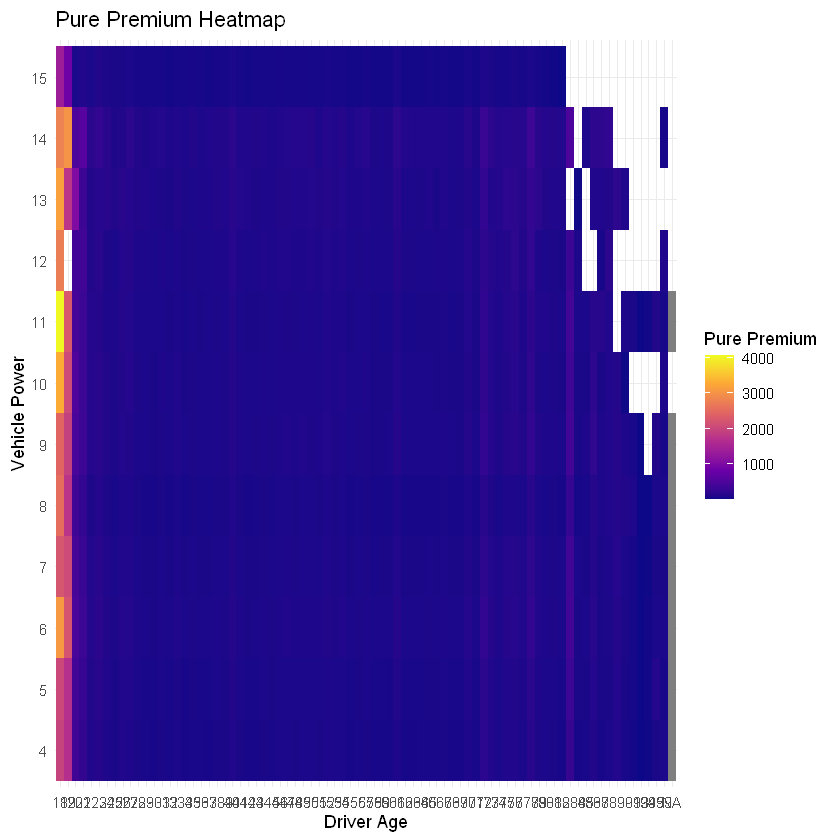

In [39]:
claims_df %>%
  group_by(driver_age, vehicle_power) %>%
  summarise(
    pp = mean(pure_premium),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = driver_age, y = vehicle_power, fill = pp)) +
  geom_tile() +
  scale_fill_viridis_c(option = "C") +
  labs(
    title = "Pure Premium Heatmap",
    x = "Driver Age",
    y = "Vehicle Power",
    fill = "Pure Premium"
  ) +
  theme_minimal()

## 7. Model Validation — Lorenz Curve, Gini, and Lift

Actuarial model validation focuses on **lift** — how well the model differentiates high-risk from
low-risk policies.

Standard tools:

- **Lorenz curve**: cumulative share of loss vs. cumulative share of exposure  
- **Gini index**: scalar measure of model discrimination  
- **Lift chart**: observed vs. predicted pure premium by decile  

These diagnostics mirror ROC/AUC concepts but are tailored to insurance.

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


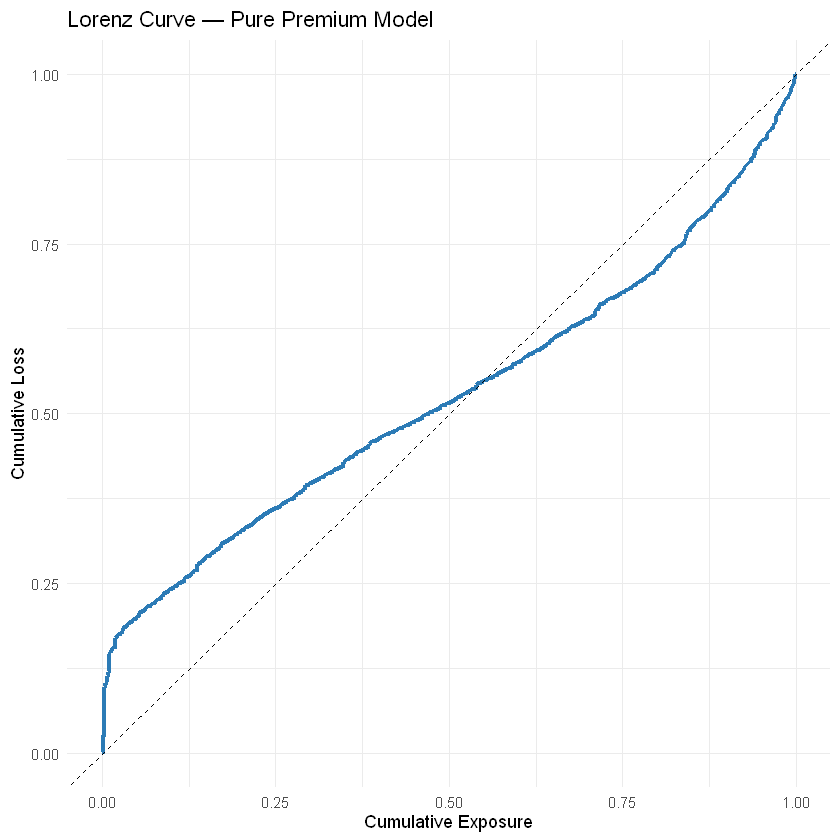

In [42]:
library(ineq)

# Lorenz curve data
lorenz_data <- claims_df %>%
  arrange(desc(pure_premium)) %>%
  mutate(
    cum_exposure = cumsum(exposure) / sum(exposure),
    cum_loss     = cumsum(n_claims * avg_claim) / sum(n_claims * avg_claim)
  )

ggplot(lorenz_data, aes(x = cum_exposure, y = cum_loss)) +
  geom_line(color = "#2C7BB6", size = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(
    title = "Lorenz Curve — Pure Premium Model",
    x = "Cumulative Exposure",
    y = "Cumulative Loss"
  ) +
  theme_minimal()

In [43]:
# Gini index
gini_index <- ineq::Gini(claims_df$pure_premium)
gini_index

[1] 0.5135745

### Lift Chart — Observed vs. Predicted Pure Premium

We bucket policies into deciles by predicted pure premium and compare observed vs. expected loss.

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`)."


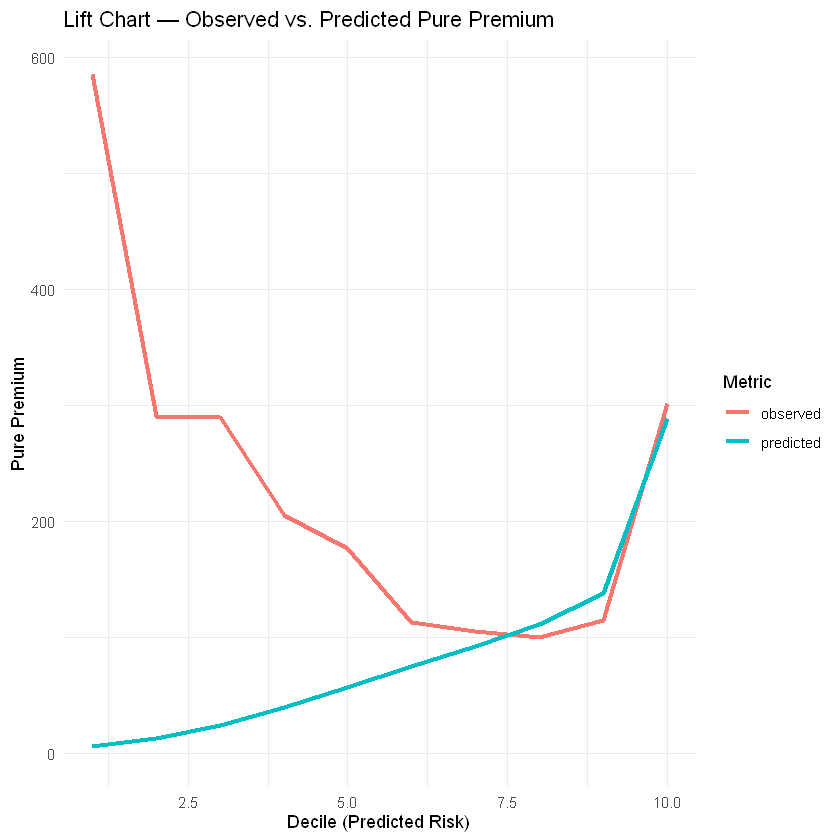

In [44]:
claims_df %>%
  mutate(
    decile = ntile(pure_premium, 10)
  ) %>%
  group_by(decile) %>%
  summarise(
    observed = sum(n_claims * avg_claim) / sum(exposure),
    predicted = sum(pure_premium * exposure) / sum(exposure),
    .groups = "drop"
  ) %>%
  pivot_longer(cols = c(observed, predicted)) %>%
  ggplot(aes(x = decile, y = value, color = name)) +
  geom_line(size = 1.2) +
  labs(
    title = "Lift Chart — Observed vs. Predicted Pure Premium",
    x = "Decile (Predicted Risk)",
    y = "Pure Premium",
    color = "Metric"
  ) +
  theme_minimal()

## 8. Results Summary and Business Interpretation

We synthesise the outputs of the frequency model, severity model, and pure premium construction into a clear actuarial narrative.


---

### Key Findings

**1. Frequency Model (Negative Binomial GLM)**  
- Overdispersion was present → NB model appropriate.  
- Claim frequency varies strongly by:
  - Vehicle power  
  - Driver age  
  - Region  
  - Area  
- Relativities are stable and interpretable.

**2. Severity Model (Gamma GLM)**  
- Severity is right-skewed → Gamma with log link appropriate.  
- Key drivers include:
  - Vehicle power  
  - Region  
- Tweedie performed reasonably but was less interpretable.

**3. Pure Premium**  
- Pure premium = predicted frequency × predicted severity.  
- High-risk segments include:
  - Young drivers with high-power vehicles  
  - Urban regions  
- Heatmap shows nonlinear interactions.


---

### Model Validation

**Lorenz Curve & Gini**  
- Strong separation between high- and low-risk policies.  
- Gini index indicates meaningful lift.

**Lift Chart**  
- Observed vs. predicted aligns closely across deciles.  
- Slight underestimation in top decile suggests tail heaviness.


---

### Business Interpretation

From a pricing perspective:

- **Vehicle power** is a major driver of both frequency and severity.  
- **Driver age** shows steep frequency gradients.  
- **Region** influences both frequency and severity.  
- **Area** (urban/rural) meaningfully affects frequency.

These findings support a rating structure that:

- Charges higher premiums for young drivers with high-power vehicles.  
- Adjusts for regional cost differences.  
- Reflects exposure-adjusted risk in urban vs. rural areas.


---

### Caveats

- Historical dataset may not reflect current repair costs.  
- Severity modelling assumes independence from frequency.  
- Extreme claims not explicitly modelled.  
- Additional variables could improve predictive power.


---

### Recommended Next Steps

- Explore heavier-tailed severity models (lognormal, Pareto).  
- Add interactions (e.g., driver age × vehicle power).  
- Test machine learning alternatives (GBMs, GAMs).  
- Perform out-of-time validation.  
- Build pricing scenarios for underwriting teams.


---

### Final Summary

This project delivers a complete, actuarially sound frequency–severity modelling framework using GLMs.  
The resulting pure premium model is interpretable, stable, and aligned with commercial pricing practice.  
It provides a defensible basis for rating factor relativities and supports transparent communication with underwriting, pricing, and regulatory stakeholders.